In [1]:
from google.colab import files
import pandas as pd
import io

print("Please upload sentiment_data.csv from your desktop...")
uploaded = files.upload()

filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

print("File loaded!")
print("Shape:", df.shape)
df.head(3)

Please upload sentiment_data.csv from your desktop...


Saving sentiment_data.csv to sentiment_data.csv
File loaded!
Shape: (22628, 14)


,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name,review_length,sentiment_label,sentiment_score,age_group
0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates,8,positive,0.6333,26-35 (Millennials)
1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses,62,positive,0.3396,26-35 (Millennials)
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses,98,neutral,0.0737,46-60


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded!")


Libraries loaded!


In [3]:
print("Current columns:")
for i, col in enumerate(df.columns.tolist()):
    print(f"  {i+1}. {col}")

print("\nData types:")
print(df.dtypes)

Current columns:
  1. Clothing ID
  2. Age
  3. Title
  4. Review Text
  5. Rating
  6. Recommended IND
  7. Positive Feedback Count
  8. Division Name
  9. Department Name
  10. Class Name
  11. review_length
  12. sentiment_label
  13. sentiment_score
  14. age_group

Data types:
Clothing ID                  int64
Age                          int64
Title                       object
Review Text                 object
Rating                       int64
Recommended IND              int64
Positive Feedback Count      int64
Division Name               object
Department Name             object
Class Name                  object
review_length                int64
sentiment_label             object
sentiment_score            float64
age_group                   object
dtype: object


In [4]:
# Normalize positive feedback count between 0 and 1
df['popularity_score'] = (
    df['Positive Feedback Count'] /
    df['Positive Feedback Count'].max()
)

print("Popularity score created!")
print("Min:", df['popularity_score'].min())
print("Max:", df['popularity_score'].max())
print("Mean:", round(df['popularity_score'].mean(), 4))

Popularity score created!
Min: 0.0
Max: 1.0
Mean: 0.0216


In [5]:
# Categorize review length into short/medium/long
def categorize_review_length(length):
    if length < 20:
        return 'short'
    elif length < 60:
        return 'medium'
    else:
        return 'long'

df['review_length_cat'] = df['review_length'].apply(categorize_review_length)

print("Review length categories created!")
print(df['review_length_cat'].value_counts())

Review length categories created!
review_length_cat
long      11162
medium     9625
short      1841
Name: count, dtype: int64


In [6]:
# Convert sentiment text to numbers for ML
sentiment_map = {
    'positive': 1,
    'neutral':  0,
    'negative': -1
}

df['sentiment_encoded'] = df['sentiment_label'].map(sentiment_map)

print("Sentiment encoded!")
print(df[['sentiment_label', 'sentiment_encoded']].drop_duplicates())

Sentiment encoded!
   sentiment_label  sentiment_encoded
0         positive                  1
2          neutral                  0
77        negative                 -1


In [7]:
# Convert text categories to numbers
le = LabelEncoder()

df['department_encoded'] = le.fit_transform(df['Department Name'])
df['class_encoded']      = le.fit_transform(df['Class Name'])
df['division_encoded']   = le.fit_transform(df['Division Name'])

print("Categories encoded!")
print("\nDepartment encoding:")
dept_map = dict(zip(df['Department Name'], df['department_encoded']))
for k, v in sorted(dept_map.items()):
    print(f"  {k} → {v}")

Categories encoded!

Department encoding:
  Bottoms → 0
  Dresses → 1
  Intimate → 2
  Jackets → 3
  Tops → 4
  Trend → 5


In [8]:
age_map = {
    '18-25 (Gen-Z)'      : 1,
    '26-35 (Millennials)': 2,
    '36-45'              : 3,
    '46-60'              : 4,
    '60+'                : 5
}

df['age_group_encoded'] = df['age_group'].map(age_map)

# Fill any nulls with median
df['age_group_encoded'] = df['age_group_encoded'].fillna(3)

print("Age group encoded!")
print(df[['age_group', 'age_group_encoded']].drop_duplicates().sort_values('age_group_encoded'))


Age group encoded!
              age_group  age_group_encoded
8         18-25 (Gen-Z)                  1
0   26-35 (Millennials)                  2
6                 36-45                  3
2                 46-60                  4
35                  60+                  5


In [9]:
# Flag products with above average positive feedback
avg_feedback = df['Positive Feedback Count'].mean()

df['high_feedback'] = (
    df['Positive Feedback Count'] > avg_feedback
).astype(int)

print(f"Average feedback count : {round(avg_feedback, 2)}")
print(f"High feedback products : {df['high_feedback'].sum()}")
print(f"Low feedback products  : {(df['high_feedback']==0).sum()}")

Average feedback count : 2.63
High feedback products : 6073
Low feedback products  : 16555


In [10]:
# These are the columns our ML model will use
ml_features = [
    'Rating',               # product rating
    'Age',                  # reviewer age
    'sentiment_score',      # how positive the review is
    'sentiment_encoded',    # sentiment as number
    'popularity_score',     # normalized feedback count
    'review_length',        # how long the review is
    'department_encoded',   # which department
    'class_encoded',        # which class
    'division_encoded',     # which division
    'age_group_encoded',    # age group number
    'high_feedback',        # above avg feedback flag
    'Recommended IND'       # TARGET variable
]

df_ml = df[ml_features].copy()

# Drop any remaining nulls
df_ml = df_ml.dropna()
df_ml = df_ml.reset_index(drop=True)

print("Final ML dataset created!")
print("Shape:", df_ml.shape)
print("\nAll columns:")
for col in df_ml.columns:
    print(f"  → {col}")

Final ML dataset created!
Shape: (22628, 12)

All columns:
  → Rating
  → Age
  → sentiment_score
  → sentiment_encoded
  → popularity_score
  → review_length
  → department_encoded
  → class_encoded
  → division_encoded
  → age_group_encoded
  → high_feedback
  → Recommended IND


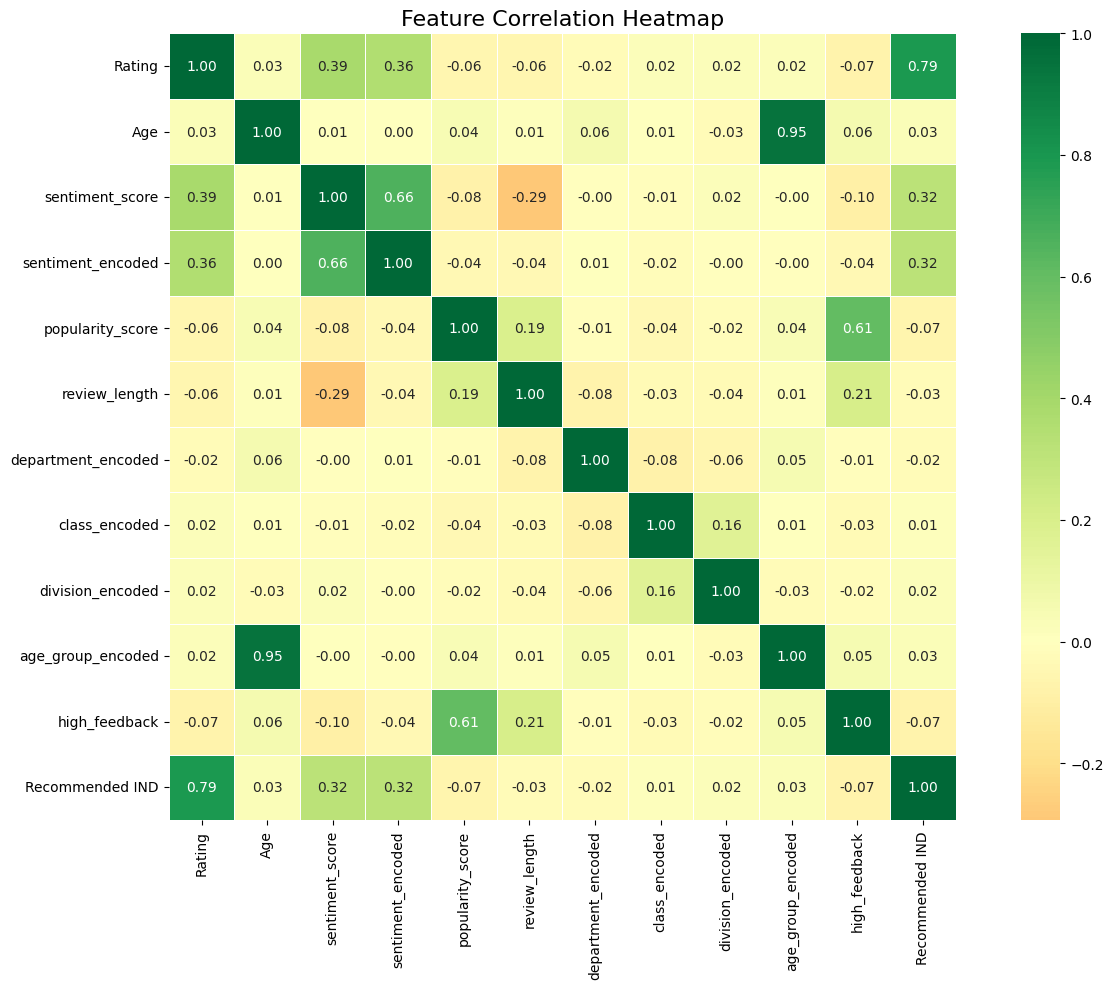


Top features correlated with Recommended IND:
Recommended IND       1.000
Rating                0.793
sentiment_score       0.321
sentiment_encoded     0.316
Age                   0.034
age_group_encoded     0.030
division_encoded      0.021
class_encoded         0.011
department_encoded   -0.022
review_length        -0.030
popularity_score     -0.066
high_feedback        -0.073
Name: Recommended IND, dtype: float64


In [11]:
plt.figure(figsize=(14, 10))

corr = df_ml.corr()

sns.heatmap(corr,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            square=True,
            linewidths=0.5)

plt.title('Feature Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.show()

print("\nTop features correlated with Recommended IND:")
print(corr['Recommended IND'].sort_values(ascending=False).round(3))

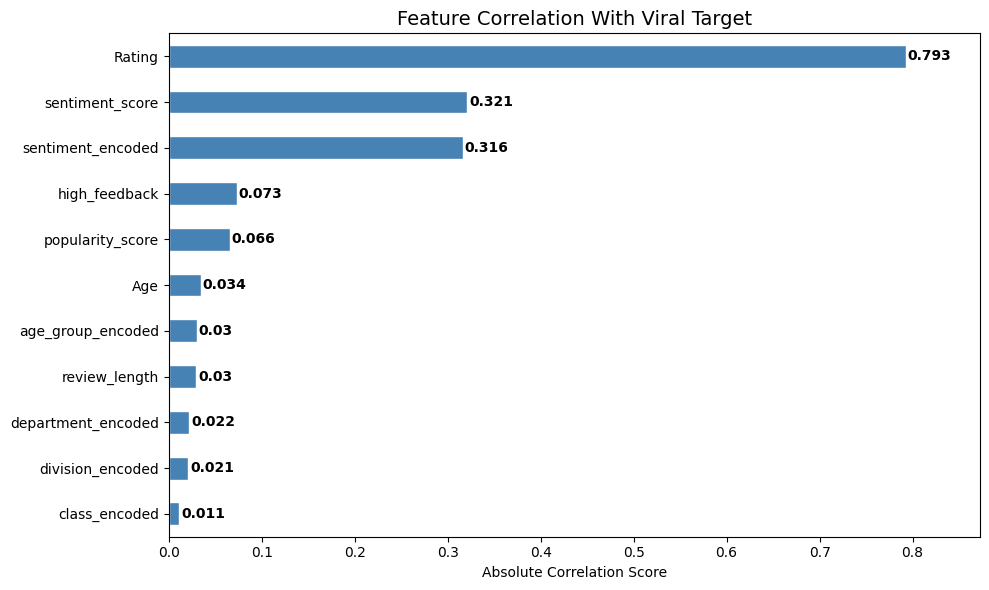

In [12]:
plt.figure(figsize=(10, 6))

# Correlation with target variable
target_corr = abs(corr['Recommended IND']).drop('Recommended IND').sort_values(ascending=True)

target_corr.plot(kind='barh', color='steelblue', edgecolor='white')

# Add values on bars
for i, v in enumerate(target_corr.values):
    plt.text(v + 0.002, i, str(round(v, 3)),
             va='center', fontweight='bold')

plt.title('Feature Correlation With Viral Target', fontsize=14)
plt.xlabel('Absolute Correlation Score')
plt.xlim(0, max(target_corr.values) + 0.08)
plt.tight_layout()
plt.show()

In [13]:
best_feature = abs(corr['Recommended IND']).drop('Recommended IND').idxmax()
best_score   = abs(corr['Recommended IND']).drop('Recommended IND').max()

print("=" * 45)
print("  TRENDLENS — FEATURE ENGINEERING INSIGHTS")
print("=" * 45)
print(f"Total features created   : {len(ml_features)-1}")
print(f"Total rows for ML        : {len(df_ml)}")
print(f"Viral products (%)       : {round(df_ml['Recommended IND'].mean()*100,1)}%")
print(f"Best predictor feature   : {best_feature}")
print(f"Its correlation score    : {round(best_score, 3)}")
print("=" * 45)

  TRENDLENS — FEATURE ENGINEERING INSIGHTS
Total features created   : 11
Total rows for ML        : 22628
Viral products (%)       : 81.9%
Best predictor feature   : Rating
Its correlation score    : 0.793


In [15]:
# Save full data
df.to_csv('sentiment_data_full.csv', index=False)

# Save ML ready data
df_ml.to_csv('final_data.csv', index=False)

print("Files saved!")
print("→ final_data.csv     (ML ready dataset)")
print("→ Shape:", df_ml.shape)

# Download both
from google.colab import files
files.download('final_data.csv')
print("Downloading final_data.csv to your desktop...")

Files saved!
→ final_data.csv     (ML ready dataset)
→ Shape: (22628, 12)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>